In [1]:
import pandas as pd
import cfe

[09/24/2025 09:31:38] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")
fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

In [3]:
cluster_edges = {
    ("Ductal", "Ngn3 low EP"),
    ("Ngn3 low EP", "Ngn3 high EP"),
    ("Ngn3 high EP", "Pre-endocrine"),
    ("Pre-endocrine", "Alpha"),
    ("Pre-endocrine", "Beta"),
    ("Pre-endocrine", "Delta"),
    ("Pre-endocrine", "Epsilon"),
}


In [4]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata, n_top_genes=2000)
scv.pp.moments(fadata)

fadata

Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:09) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


AnnData object with n_obs × n_vars = 500 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'cfe', 'log1p', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

## Visualization and metric comparison of real velocity and pseudo velocity.

[09/24/2025 09:31:51] INFO     method backend loaded: CondaBackend: scvelo in conda env 'cfe'                                                                                                           
                      INFO     cmd: conda run -n cfe --no-capture-output python /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/parse_args.py --function_name=scvelo     
                               --adata_path=/tmp/tmpvtd9_gh_/adata.h5ad --parameters=/tmp/tmpvtd9_gh_/parameters.json --output_filename=/tmp/tmpvtd9_gh_/output.pkl                                     
[09/24/2025 09:31:58] INFO     [stdout]computing velocities                                                                                                                                             
[09/24/2025 09:31:59] INFO     [stdout]    finished (0:00:00) --> added                                                                                                                             

<Axes: title={'center': 'clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

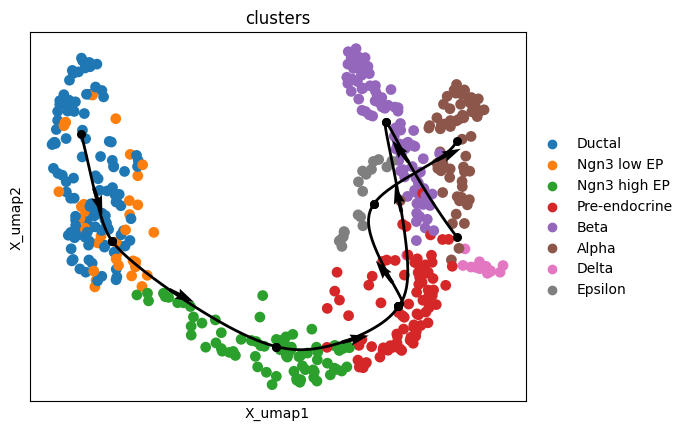

In [5]:
method = cfe.method.FateMethod(method_name="scvelo")
method.infer_trajectory(fadata, parameters={"repreprocess": False})
cfe.plot.plot_trajectory(fadata, color="clusters")

metric and visualization comparision

[09/24/2025 09:32:07] INFO     find wrapper type: velocity                                                                                                                                              


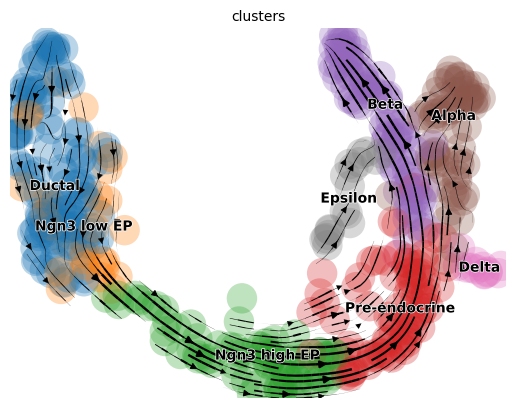

{'CBDir': 0.5784449615225729, 'ICVCoh': 0.8542959747413561}
[09/24/2025 09:32:09] INFO     recompute pseudo velocity                                                                                                                                                
                      INFO     find wrapper type: velocity                                                                                                                                              


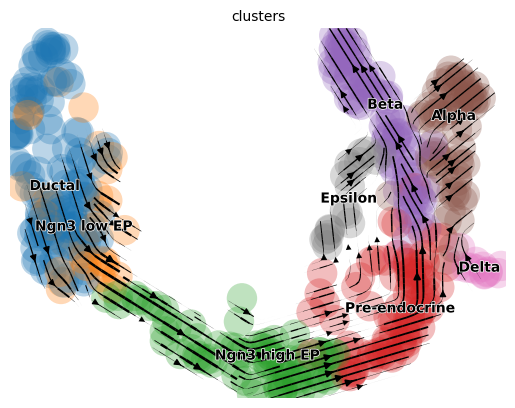

{'CBDir': 0.4638203666079743, 'ICVCoh': 0.7424311757706124}


In [6]:
# real_velocity, skip compute pseudo velocity
real_velocity_metrics = cfe.metric.calculate_velocity_metrics(fadata, cluster_edges=cluster_edges)
cfe.plot.plot_wrapper(fadata)
print(real_velocity_metrics)

# recompute pseudo velocity
pseudo_velocity_metrics = cfe.metric.calculate_velocity_metrics(fadata, cluster_edges=cluster_edges,recompute_pseudo_velocity=True)
cfe.plot.plot_wrapper(fadata)
print(pseudo_velocity_metrics)

## metric comparision between different methods

In [9]:
method = cfe.method.FateMethod(method_name="comp1")
method.infer_trajectory(fadata, parameters={"repreprocess": False})

[09/24/2025 09:32:47] INFO     method backend loaded: CondaBackend: comp1 in conda env 'cfe'                                                                                                            
                      INFO     cmd: conda run -n cfe --no-capture-output python /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/parse_args.py --function_name=comp1      
                               --adata_path=/tmp/tmpxk79fx9a/adata.h5ad --parameters=/tmp/tmpxk79fx9a/parameters.json --output_filename=/tmp/tmpxk79fx9a/output.pkl                                     
[09/24/2025 09:32:55] INFO     [stdout]comp1 finish!                                                                                                                                                    
[09/24/2025 09:32:57] INFO     method infer trajectory successfully: CondaBackend: comp1 in conda env 'cfe'                                                                                         

In [ ]:
fadata.get_all_model_name(parse=False)

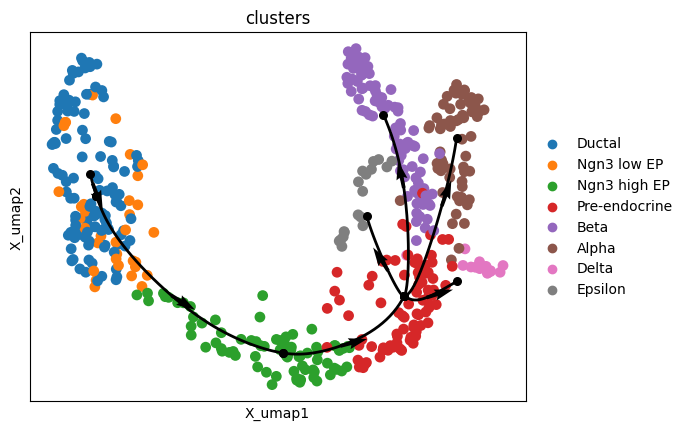

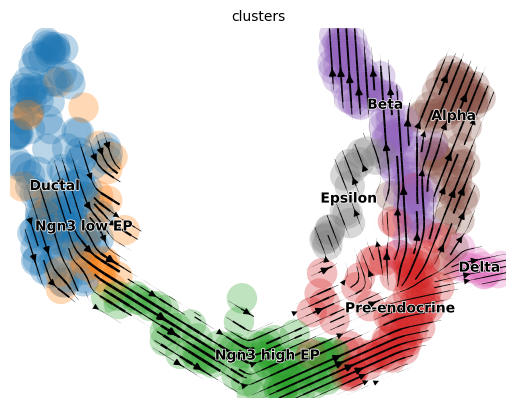

ref {'CBDir': 0.41850752087580656, 'ICVCoh': 0.8807664049418391}


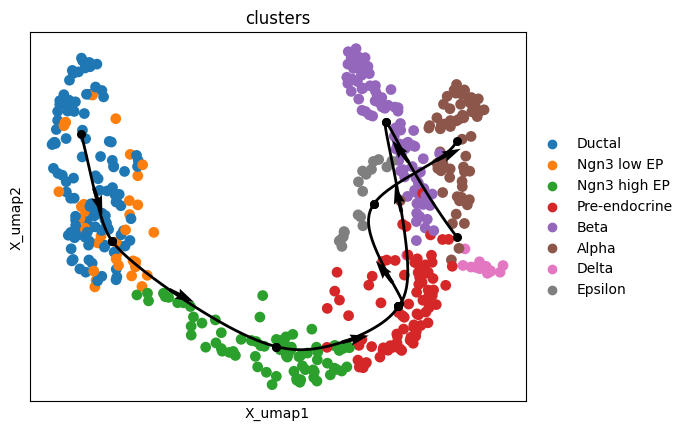

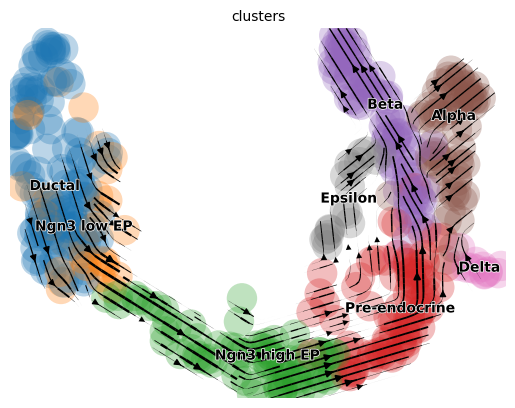

20250924_213151__scvelo-conda__HFyfbmTVw2 {'CBDir': 0.4638203666079743, 'ICVCoh': 0.7424311757706124}


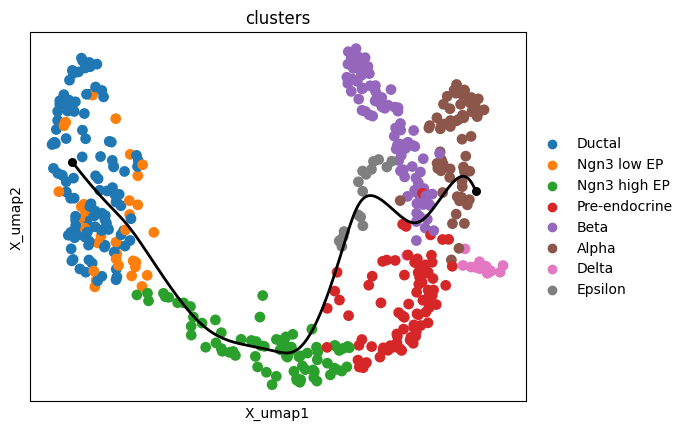

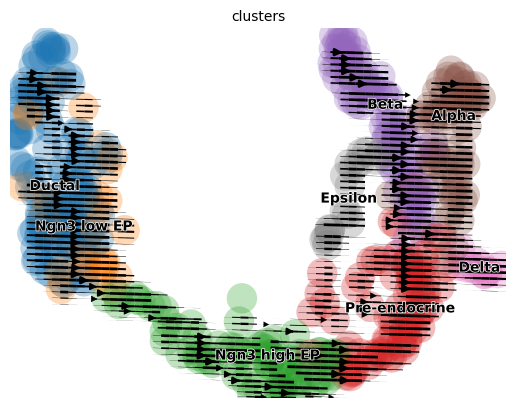

20250924_213247__comp1-conda__MgqOfF30wM {'CBDir': 0.3590662691096857, 'ICVCoh': 0.9980242844999169}


In [11]:
metric_dict = {}
for model_name in fadata.get_all_model_name(parse=False):
    velocity_metrics = cfe.metric.calculate_velocity_metrics(fadata, model_name=model_name, cluster_edges=cluster_edges)
    cfe.plot.plot_trajectory(fadata, model_name=model_name)
    cfe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity")
    metric_dict[model_name] = velocity_metrics
    print(model_name, velocity_metrics)

In [21]:
metric_df = pd.DataFrame(metric_dict).T
metric_df.round(3)

,CBDir,ICVCoh
ref,0.42,0.88
20250924_213151__scvelo-conda__HFyfbmTVw2,0.46,0.74
20250924_213247__comp1-conda__MgqOfF30wM,0.36,1.00
